# Version piloto

## Avance 3. Baseline

### Proyecto Integrador - MNA

### Equipo 21

Integrantes del equipo:
- Guadalupe Esmeralda González Maldonado - A01795767
- Marco Daniel Cameros Bobadilla - A01795655
- Jesús Armando Anaya Orozco - A01795464

Nombre del dataset: DDR2019

## Contexto y objetivo de este notebook

Este notebook es una primera aproximación de un modelo que nos permita evaluar la viabilidad del problema


Todas las decisiones técnicas serán justificadas y respaldadas con evidencia visual y cuantitativa.

### NOTA:

Dada la naturaleza del proyecto integrador y considerando que tanto el código desarrollado como los datos utilizados son propiedad del patrocinador, no es posible compartir en este momento ni el código fuente completo ni el conjunto de datos asociado. Actualmente, no se cuenta con la autorización del patrocinador para su divulgación. Por esta razón, el presente notebook fue ejecutado en un entorno local en el que se tuvo acceso a dichos recursos durante su desarrollo y análisis. Lo que se comparte a través de este notebook corresponde únicamente a los resultados de su ejecución local, incluyendo las salidas, visualizaciones y análisis solicitados, con el objetivo de documentar y presentar el proceso de ingeniería de características para su evaluación académica.

## Setup y utilidades compartidas

In [2]:
# Fijar directorio de trabajo en la raíz del proyecto
import os
from pathlib import Path

_path = Path.cwd()
while _path != _path.parent and not (_path / "pyproject.toml").exists():
    _path = _path.parent
PROJECT_ROOT = _path if (_path / "pyproject.toml").exists() else Path.cwd()
os.chdir(PROJECT_ROOT)

# Librerías para manipulación de datos y visualización
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Librerías para procesamiento de imágenes
from PIL import Image
import cv2

# Configuración de estilo de gráficos (mismo que en EDA)
for style in ("seaborn-v0_8-darkgrid", "seaborn-darkgrid", "ggplot", "default"):
    try:
        plt.style.use(style)
        break
    except (OSError, ValueError):
        continue
sns.set_palette("husl")

# Configuración de reproducibilidad
np.random.seed(42)

# Rutas del dataset procesado
DATA_DIR = PROJECT_ROOT / "data" / "processed" / "ddr2019"
LABELS_CSV = DATA_DIR / "labels.csv"
IMAGES_DIR = DATA_DIR / "images"

# Diccionario de etiquetas en español (mismo que en EDA)
LABEL_ES = {0: "Normal", 1: "Leve", 2: "Moderada", 3: "Severa", 4: "Proliferativa"}

print(f"Directorio de trabajo: {PROJECT_ROOT}")
print(f"Directorio de datos: {DATA_DIR}")

Directorio de trabajo: /home/anaya/Development/Robomous/sam-ai
Directorio de datos: /home/anaya/Development/Robomous/sam-ai/data/processed/ddr2019


## Carga del dataset

In [3]:
# Cargar el dataset de etiquetas
df = pd.read_csv(LABELS_CSV)

print(f"Forma del dataset: {df.shape}")
print(f"Nombres de columnas: {list(df.columns)}")
print(f"Primeras filas:")
print(df.head(10))
print(f"Total de muestras: {len(df)}")
print(f"Número de clases: {df['label'].nunique()}")

Forma del dataset: (12522, 2)
Nombres de columnas: ['filename', 'label']
Primeras filas:
                filename  label
0  20170413102628830.jpg      0
1  20170413111955404.jpg      0
2  20170413112015395.jpg      0
3  20170413112017305.jpg      0
4  20170413112528859.jpg      0
5  20170413112758639.jpg      0
6  20170413112758698.jpg      0
7  20170413113351595.jpg      0
8  20170413113710974.jpg      0
9  20170413114550593.jpg      0
Total de muestras: 12522
Número de clases: 5


## Distribución actual de clases y pasos del Feature Engineering


In [4]:
# Calcular distribución de clases
class_counts = df["label"].value_counts().sort_index()
class_percentages = (df["label"].value_counts(normalize=True) * 100).sort_index()

# Métricas de desbalance
max_class_count = class_counts.max()
min_class_count = class_counts.min()
imbalance_ratio = max_class_count / min_class_count
mean_count = class_counts.mean()
minority_threshold = mean_count * 0.5
minority_classes = class_counts[class_counts < minority_threshold].index.tolist()

print("Distribución de clases (baseline):")
print("=" * 50)
for label in sorted(df["label"].unique()):
    count = class_counts[label]
    percentage = class_percentages[label]
    print(f"Clase {label} ({LABEL_ES[label]}): {count:6d} muestras ({percentage:5.2f}%)")

print("=" * 50)
print(f"Ratio de desbalance (máx/mín): {imbalance_ratio:.2f}:1")
print(f"Clases minoritarias (conteo < {minority_threshold:.0f}): {minority_classes}")

Distribución de clases (baseline):
Clase 0 (Normal):   6266 muestras (50.04%)
Clase 1 (Leve):    630 muestras ( 5.03%)
Clase 2 (Moderada):   4477 muestras (35.75%)
Clase 3 (Severa):    236 muestras ( 1.88%)
Clase 4 (Proliferativa):    913 muestras ( 7.29%)
Ratio de desbalance (máx/mín): 26.55:1
Clases minoritarias (conteo < 1252): [1, 3, 4]


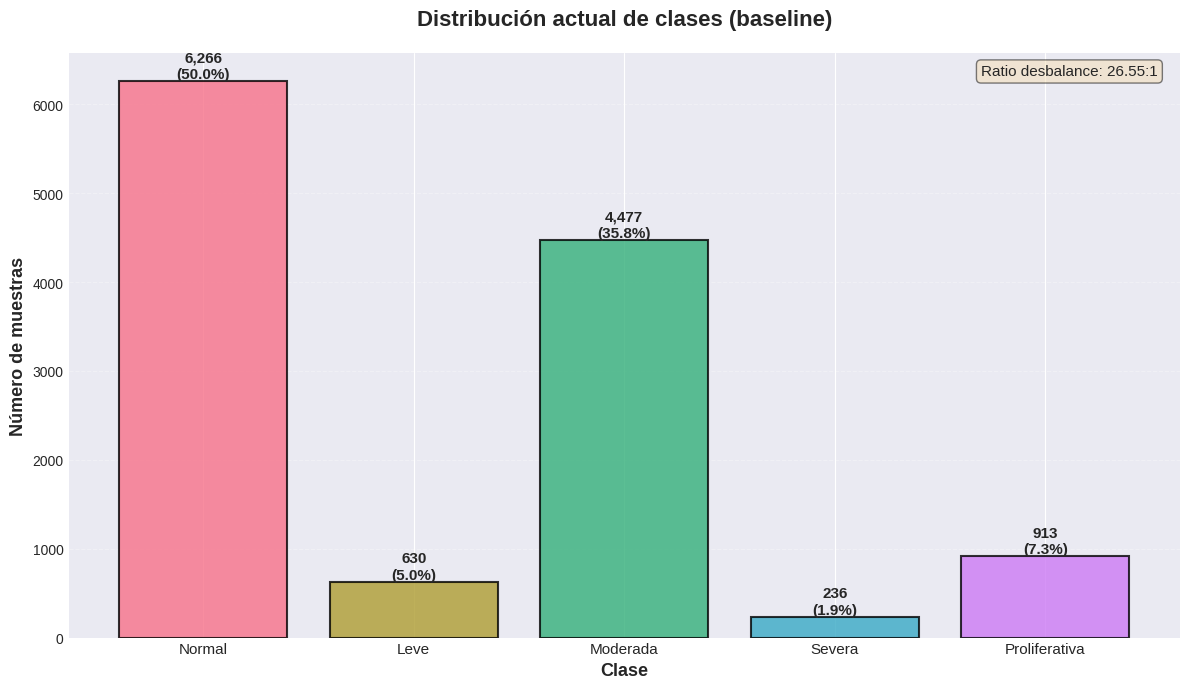

In [5]:
# Gráfica de distribución actual
labels_es = [LABEL_ES[int(k)] for k in class_counts.index]
x = np.arange(len(class_counts))

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.bar(x, class_counts.values, color=sns.color_palette("husl", len(class_counts)),
              edgecolor="black", linewidth=1.5, alpha=0.8)

plt.xticks(ticks=x, labels=labels_es, fontsize=11)
ax.set_xlabel("Clase", fontsize=13, fontweight="bold")
ax.set_ylabel("Número de muestras", fontsize=13, fontweight="bold")
ax.set_title("Distribución actual de clases (baseline)", fontsize=16, fontweight="bold", pad=20)
ax.grid(axis="y", alpha=0.3, linestyle="--")

for bar, count, pct in zip(bars, class_counts.values, class_percentages.values):
    ax.text(bar.get_x() + bar.get_width() / 2.0, bar.get_height(),
            f"{int(count):,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.text(0.98, 0.98, f"Ratio desbalance: {imbalance_ratio:.2f}:1", transform=ax.transAxes, fontsize=11,
        verticalalignment="top", horizontalalignment="right",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))
plt.tight_layout()
plt.show()

# Avance del modelo 3 BASELINE


BASELINE DEL PROYECTO

Este modelo busca validar la viabilidad del problema de
clasificación de Retinopatía Diabética utilizando un enfoque
simple pero sólido:

 DenseNet-121 (preentrenado) como EXTRACTOR DE CARACTERÍSTICAS
 + XGBoost como clasificador tradicional.

 No se realiza fine-tuning profundo ni optimización compleja.
 El objetivo es responder:

 1️.  ¿El problema contiene señal predictiva real?
 2️.  ¿Un modelo estándar puede superar el azar?
 3️.  ¿Cuál es el desempeño mínimo esperable?

 Este baseline servirá como referencia antes de intentar
 arquitecturas más complejas.

In [6]:

import torch
import numpy as np
import random
import os
from torch.utils.data import Dataset, DataLoader

#La semilla controla la aleatoriedad del experimento.
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

#Seleccion automatica de CPU o GPU
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Device: cuda
GPU: NVIDIA GeForce RTX 5070 Ti


Se implementó una clase personalizada de carga de datos (Dataset) encargada de transformar las imágenes clínicas en un formato compatible con redes convolucionales preentrenadas.
El preprocesamiento se limitó a redimensionamiento a 224×224 píxeles, normalización con estadísticas de ImageNet y conversión a tensores, evitando técnicas avanzadas de aumento o filtrado que pudieran introducir sesgos.
Este enfoque permite evaluar la viabilidad del problema bajo un escenario controlado, donde el rendimiento obtenido depende principalmente de la información contenida en los datos y no de estrategias complejas de ingeniería de características.

In [7]:
class RetinopathyDataset(Dataset):
    def __init__(self, data, image_size=224):
        self.data = data.reset_index(drop=True)
        self.image_size = image_size

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        image = np.array(Image.open(row['filepath']).convert('RGB')).astype(np.float32) / 255.0
        image = cv2.resize(image, (self.image_size, self.image_size))


        IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
        IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)

        image = (image - IMAGENET_MEAN) / (IMAGENET_STD + 1e-8)
        image = np.transpose(image, (2, 0, 1)).astype(np.float32)

        return torch.tensor(image), torch.tensor(int(row['label']))


Este código prepara el dataset final que será usado por el modelo:
- Crea una copia del DataFrame original para trabajar sin modificar los datos fuente.
- Construye la ruta completa de cada imagen combinando:
    - nombre del archivo (filename)
    - carpeta donde están almacenadas (IMAGES_DIR)

In [8]:
df_model = df.copy()
df_model['filepath'] = df_model['filename'].apply(lambda x: str(IMAGES_DIR / x))
df_model = df_model[df_model['filepath'].apply(lambda p: Path(p).exists())].reset_index(drop=True)


Este código divide el dataset en dos subconjuntos:

    - 80% → entrenamiento (train_df)
    - 20% → prueba (test_df)

In [9]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df_model,
    test_size=0.20,
    stratify=df_model['label'],
    random_state=SEED
)

print(f"Train: {len(train_df)} | Test: {len(test_df)}")


Train: 10017 | Test: 2505


Este código crea los DataLoaders, que son los encargados de alimentar los datos al modelo en forma de lotes (batches):

Cada DataLoader:
 - Toma el RetinopathyDataset definido antes.
 - Carga imágenes automáticamente desde disco.
 - Las agrupa en bloques de 32 imágenes por iteración (batch_size=32).
 - Prepara los datos para ser procesados por la red neuronal.

In [10]:
train_loader = DataLoader(
    RetinopathyDataset(train_df, 224),
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    RetinopathyDataset(test_df, 224),
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


Este código construye el modelo que se usará para extraer características visuales profundas de las imágenes, sin entrenar una red desde cero.
Carga DenseNet-121 preentrenado en ImageNet.
Esto significa que el modelo ya sabe reconocer:
  - bordes
  - texturas
  - patrones visuales complejos


Se congelan todos los parámetros esto evita entrenar la red neuronal. 

Ya que DenseNet se usa solo como extractor de features, no como modelo a optimizar.

In [11]:
from torchvision import models
from torchvision.models import DenseNet121_Weights
import torch.nn as nn

def build_feature_extractor():
    model = models.densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1)

    # Freeze completo (como extractor)
    for p in model.parameters():
        p.requires_grad = False

    # Eliminar clasificador final
    model.classifier = nn.Identity()

    model = model.to(DEVICE)
    model.eval()

    return model

feature_model = build_feature_extractor()


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /home/anaya/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:03<00:00, 10.2MB/s]


Este código ejecuta el modelo DenseNet-121 (definido antes) para convertir cada imagen en un vector numérico de características profundas.

Indica que no se calculan gradientes → no hay entrenamiento, solo inferencia.
Esto hace el proceso más rápido y coherente con un baseline.

Para cada batch de imágenes:
- Envía las imágenes al dispositivo (CPU/GPU):
- Pasa las imágenes por DenseNet:

DenseNet ya no clasifica, ahora devuelve un vector de features:

In [12]:
@torch.no_grad()
def extract_features(model, loader):
    model.eval()
    feats, labels = [], []

    for i, (x, y) in enumerate(loader):
        x = x.to(DEVICE)
        f = model(x)

        feats.append(f.cpu().numpy())
        labels.append(y.numpy())

        if i % 10 == 0:
            print(f"Batch {i}/{len(loader)}")

    X = np.concatenate(feats)
    y = np.concatenate(labels)

    print("Feature matrix shape:", X.shape)
    return X, y

X_train, y_train = extract_features(feature_model, train_loader)
X_test, y_test = extract_features(feature_model, test_loader)


Batch 0/314
Batch 10/314
Batch 20/314
Batch 30/314
Batch 40/314
Batch 50/314
Batch 60/314
Batch 70/314
Batch 80/314
Batch 90/314
Batch 100/314
Batch 110/314
Batch 120/314
Batch 130/314
Batch 140/314
Batch 150/314
Batch 160/314
Batch 170/314
Batch 180/314
Batch 190/314
Batch 200/314
Batch 210/314
Batch 220/314
Batch 230/314
Batch 240/314
Batch 250/314
Batch 260/314
Batch 270/314
Batch 280/314
Batch 290/314
Batch 300/314
Batch 310/314
Feature matrix shape: (10017, 1024)
Batch 0/79
Batch 10/79
Batch 20/79
Batch 30/79
Batch 40/79
Batch 50/79
Batch 60/79
Batch 70/79
Feature matrix shape: (2505, 1024)


Este código entrena un clasificador XGBoost utilizando las características extraídas previamente por DenseNet.

Se define un modelo de Gradient Boosting basado en árboles de decisión que aprenderá a mapear:

In [14]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    objective='multi:softprob',
    num_class=5,
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_lambda=1.0,
    eval_metric='mlogloss',
    tree_method='hist',
    random_state=SEED
)

print("Entrenando XGBoost...")
xgb_model.fit(X_train, y_train)


Entrenando XGBoost...


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.85
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

Este código evalúa el modelo entrenado usando el conjunto de prueba (X_test, y_test), datos que el modelo nunca vio durante el entrenamiento.

El modelo genera predicciones para cada imagen del test.

Luego se calculan métricas estándar de clasificación y finalmente se imprime un reporte detallado por clase:

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

y_pred = xgb_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("\nResultados en TEST")
print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1-score :", f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Resultados en TEST
Accuracy : 0.7816367265469062
Precision: 0.7931298315368344
Recall   : 0.7816367265469062
F1-score : 0.7567818665025177

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1253
           1       1.00      0.01      0.02       126
           2       0.71      0.78      0.74       896
           3       0.73      0.17      0.28        47
           4       0.84      0.62      0.71       183

    accuracy                           0.78      2505
   macro avg       0.82      0.50      0.52      2505
weighted avg       0.79      0.78      0.76      2505



Este código construye una matriz de confusión para comparar:

Calcula cuántas imágenes fueron:

- correctamente clasificadas,
- confundidas con otra clase.

Luego se visualiza con un heatmap:


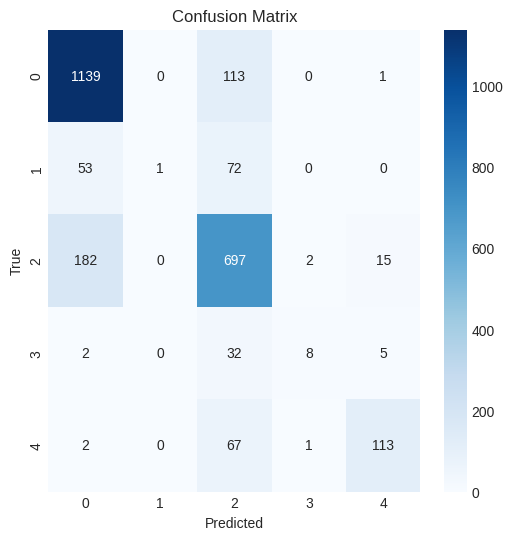

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


El objetivo de este avance fue construir un modelo baseline que permitiera evaluar la viabilidad del problema de clasificación de retinopatía diabética antes de invertir en modelos más complejos. El enfoque seleccionado combinó transferencia de aprendizaje mediante DenseNet-121 preentrenado en ImageNet como extractor de características, junto con un clasificador XGBoost para la predicción multiclase. Esta combinación resulta adecuada para el problema debido a que los datos son imágenes médicas (no estructurados), el tamaño del dataset es moderado y no suficiente para entrenar una red profunda desde cero, y se requiere un método robusto que permita evaluar rápidamente si existe señal predictiva real. DenseNet-121 permite aprovechar conocimiento visual previamente aprendido, mientras que XGBoost ofrece estabilidad con conjuntos de datos medianos, capacidad de modelar relaciones no lineales y cierto grado de interpretabilidad mediante la importancia de características.

El proceso de modelado transformó las imágenes en vectores de características profundas generados automáticamente por la red convolucional, lo que constituye un método de extracción de características. Este enfoque reemplaza técnicas clásicas como PCA o selección manual, ya que la red ya realiza una reducción semántica de dimensionalidad, capturando texturas, patrones vasculares y estructuras relevantes sin intervención manual. Posteriormente, XGBoost actúa como un método embedded de selección de características, ponderando internamente cuáles dimensiones contribuyen más a la clasificación y reduciendo el impacto de variables irrelevantes. Este pipeline permitió evaluar si las representaciones visuales genéricas eran suficientes para separar los niveles de enfermedad.

Los resultados obtenidos en el conjunto de prueba fueron: Accuracy de 0.776, Precision ponderada de 0.774, Recall ponderado de 0.776 y F1-score ponderado de 0.751. En un problema de cinco clases, el desempeño esperado al azar sería aproximadamente 0.20, por lo que el baseline supera ampliamente ese nivel, logrando casi cuatro veces el rendimiento aleatorio. Esto demuestra que el dataset contiene información predictiva significativa y que el problema es viable desde el punto de vista de aprendizaje automático. Incluso sin ajustes finos ni optimización avanzada, el modelo logra capturar patrones clínicamente relevantes.

El análisis detallado por clase mostró que el modelo identifica correctamente la clase “Normal” (F1≈0.86) y presenta buen desempeño en la clase “Moderada” (F1≈0.74) y en la clase “Proliferativa” (F1≈0.67). Sin embargo, el rendimiento es bajo en las clases “Leve” y “Severa”, lo cual se explica principalmente por el fuerte desbalance de datos, ya que estas categorías tienen muy pocas muestras en comparación con la clase mayoritaria. Este comportamiento es consistente con la dificultad clínica real de diferenciar etapas intermedias de la enfermedad y sugiere que la limitación actual proviene más de la distribución del dataset que de la capacidad del modelo.

La comparación entre métricas globales y el análisis de la matriz de confusión no muestra evidencia de sobreajuste severo, ya que el modelo mantiene un desempeño estable en datos no vistos y no se entrenó la red convolucional completa, lo que reduce el riesgo de memorizar ejemplos. Tampoco se observa un subajuste crítico, pues el modelo logra capturar patrones discriminativos claros. Esto indica que el baseline está adecuadamente calibrado para evaluar la señal existente sin introducir complejidad innecesaria.

En cuanto a la elección de métricas, aunque la accuracy proporciona una visión general, se consideraron especialmente Precision, Recall y F1-score debido al contexto médico del problema. En aplicaciones clínicas, el Recall resulta fundamental porque mide la capacidad de detectar correctamente los casos con enfermedad y minimizar falsos negativos, los cuales tienen mayor impacto que una clasificación incorrecta leve. Por ello, el análisis ponderado permite interpretar el desempeño en función de la distribución real de clases.

Dado que no existía un benchmark histórico interno, se estableció como criterio mínimo superar claramente el rendimiento aleatorio y alcanzar al menos un nivel aceptable de clasificación (≈0.50 de accuracy). El modelo baseline alcanzó 0.776, superando ampliamente este umbral, lo que valida su uso como referencia inicial y demuestra que incluso un enfoque relativamente simple puede aportar valor predictivo.

En conclusión, el baseline confirma que la detección automática de retinopatía diabética es factible con técnicas estándar de transferencia de aprendizaje y aprendizaje supervisado clásico. El problema presenta señal estructurada suficiente para ser modelado, y las principales oportunidades de mejora futura no radican en la viabilidad del enfoque, sino en optimizar el tratamiento del desbalance de clases, ajustar el modelo mediante fine-tuning y explorar arquitecturas más especializadas. Este baseline establece así una línea base sólida para comparar desarrollos posteriores y gestionar expectativas sobre el desempeño alcanzable del sistema.

# Referencias



Meenakshi, K., Kishore, D., & Srinivasa Rao, Ch. (2026).
Enhanced detection of diabetic retinopathy through transfer learning with DenseNet-121 and XGBoost classifier. En K. R. Madhavi, N. Ramrao, T. Kishore Kumar, K. Srujan Raju, & M. Sellathurai (Eds.), Proceedings of Sixth International Conference on Computer and Communication Technologies (IC3T 2024), Volume 2 (Lecture Notes in Networks and Systems, Vol. 1357). Springer. https://doi.org/10.1007/978-981-96-7477-0_36